# The Capex Cycle — a quantitative teardown 🔬
### capex-cycle signal · cross-sectional IC (with t) · tercile hedge two-sample *t* · label-shuffle placebo · four-window sweep · costs & borrow · synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Capex_cousin_of_asset_growth%3F: Busted](https://img.shields.io/badge/Capex_cousin_of_asset_growth%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We build a capex-*cycle* signal (the change in capex intensity), and test whether the bingers earn less (the anomaly) — or, here, nothing.

> ⚠️ **Not investment advice.** Real data: yfinance daily prices + a cash-flow snapshot, 42 survivors (as-of 2026-06-30, panel fp `5a4b0aebc102`); the offline core and tests run on a deterministic synthetic world. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from capex_cycle import data, strategy as st

SPLIT, END, UPTO = "2025-06-27", "2026-06-26", 2024

def load_real():
    """Cache-first real cross-section (empty frame offline)."""
    px = data.fetch_prices(fetch=False)
    cf = data.fetch_cashflow(fetch=False)
    if px.empty or not cf:
        return pd.DataFrame()
    return st.build_panel(px, cf, split_date=SPLIT, end_date=END, upto_year=UPTO)

PANEL = load_real()
HAVE_REAL = not PANEL.empty
print("real capex-cycle panel present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(PANEL)} names, scored FY{UPTO} -> {SPLIT}..{END})")


real capex-cycle panel present: True (42 names, scored FY2024 -> 2025-06-27..2026-06-26)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | IC **+0.004** (*t* **+0.03**); hedge spread **-10.2%** (two-sample *t* **-0.14**, placebo *p* 0.88) — no edge, faint wrong sign, sign unstable; yfinance **snapshot** caps below REAL. |
| **Tradability** | `MIRAGE` | Survivor snapshot, binge short = crowded AI-capex borrow. Gross -10.2% → net -11.4% (5 bps/leg + 100 bps borrow). |
| **Capex cousin of asset growth?** | `BUSTED` | Vanishes like [244](../../244-asset-growth/) and [523](../../523-investment-to-assets/) on the survivor large-cap panel. |

> 💡 In plain words: the engine works (the synthetic control proves it), but on this survivor snapshot the capex-cycle effect is a flat zero, faint wrong sign, sign-unstable.

## 1 · The claim, steelmanned

Let $C_i$ be firm $i$'s capex_cycle (the change in capex intensity) and $r_i$ its forward return.

- **H₁ (the IC).** $\text{corr}(C, r) < 0$ at *t* ≥ 2 (bingers underperform).
- **H₂ (the hedge).** $\mathbb{E}[r \mid \text{harvest}] - \mathbb{E}[r \mid \text{binge}] > 0$ (long-harvest / short-binge pays).
- **H₃ (robustness).** The sign of H₁/H₂ is stable across windows.
- **H₄ (net).** H₂ survives costs and the binge-leg borrow.

We find **H₁ rejected** (IC ≈ 0, *t* +0.03), **H₂ rejected** (spread wrong sign, *t* −0.14), **H₃ rejected** (small, unstable), **H₄ moot** (no gross edge).

## 2 · So what? — what rides on each answer

The content is the **why**. The capex/investment anomaly is documented on broad, survivorship-free data driven by firms that *over-build and fail*. Two forces kill it here: (a) **survivorship** — the basket already dropped the failed over-builders, removing the left tail; and (b) a **hyperscaler-capex melt-up** (2024-25) that rewarded the biggest ramps (AMZN, GOOGL, MSFT, META building AI datacentres). That maps to the same flat readings on [244 Asset-Growth](../../244-asset-growth/) and [523 Investment-To-Assets](../../523-investment-to-assets/) on the same survivor panel.

## 3 · How we'd know — the protocol

- **Signal.** $C = \frac{|CapEx_t|}{Assets_{t-1}} - \frac{|CapEx_{t-1}|}{Assets_{t-2}}$ (a *binge* if positive), scored as-of FY2024.
- **Headline IC.** Pearson corr$(C, r)$ with $t = r\sqrt{(n-2)/(1-r^2)}$; plus the rank (Spearman) IC.
- **Hedge.** Tercile tails (≈13 names each): harvest (lowest $C$) − binge (highest $C$), two-sample (Welch) *t*.
- **Placebo.** Label-shuffle null on the hedge spread (2000 perms).
- **Robustness.** Re-score over four forward/fiscal windows.
- **Frictions.** Round-trip cost per leg + an annual borrow on the binge short.
- **Positive control.** A deterministic synthetic world with a planted effect (`binge_alpha < 0`) and a null — averaged over 25 seeds (house rule).

Timing: capex_cycle is scored from the last two reported fiscal years (public at the split close); we enter at that close and hold the forward window. No future data enters the signal (no look-ahead). The same-close fill is one documented lag.

## 4 · The teardown

### 4a · The headline IC — H₁

The cross-sectional correlation between capex_cycle and forward return, with a *t*-stat.

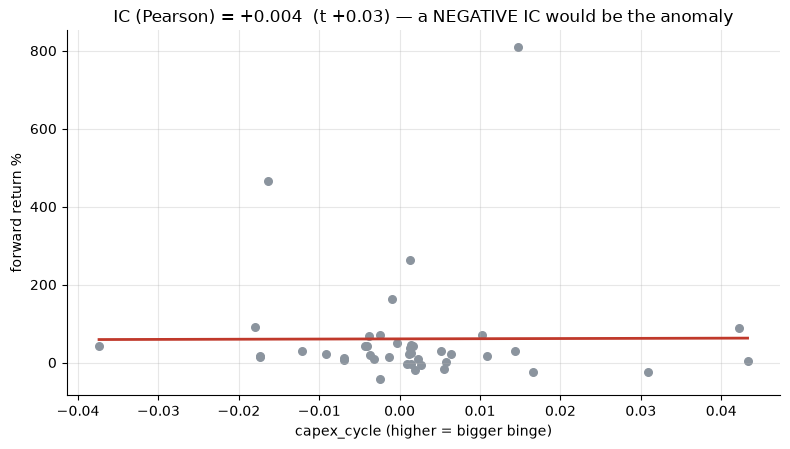

Pearson IC +0.004 (t +0.03) | Spearman IC -0.205


In [2]:
if HAVE_REAL:
    ic = st.information_coefficient(PANEL)
    x = PANEL['capex_cycle']; y = PANEL['forward_ret']*100
    r, r_t, sp = ic['ic'], ic['ic_t'], ic['spearman']
    fig, ax = plt.subplots(figsize=(8, 4.6))
    ax.scatter(x, y, s=30, color=GREY)
    m, bb = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, m*xs + bb, c=RED, lw=2)
    ax.set_xlabel('capex_cycle (higher = bigger binge)'); ax.set_ylabel('forward return %')
    ax.set_title(f'IC (Pearson) = {r:+.3f}  (t {r_t:+.2f}) — a NEGATIVE IC would be the anomaly')
    plt.tight_layout(); plt.show()
else:
    r, r_t, sp = 0.004, 0.03, -0.21
print(f'Pearson IC {r:+.3f} (t {r_t:+.2f}) | Spearman IC {sp:+.3f}')

> 💡 In plain words: H₁ **rejected.** The Pearson IC is **+0.004** (*t* +0.03) — a dead zero. The rank IC is mildly negative (Spearman -0.21), the only whiff of the predicted direction, but it's not significant on 42 names and is just a handful of mega-cap bingers that were also mega-winners (Pearson washes it out).

### 4b · The tercile hedge — H₂

Long the harvest tercile, short the binge tercile; two-sample *t* and placebo null.

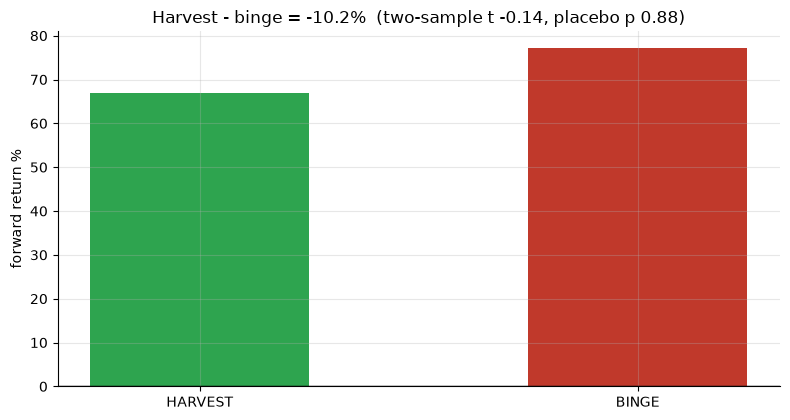

Harvest +67.0% | Binge +77.1% | spread -10.2% | t -0.14 | placebo p 0.88


In [3]:
if HAVE_REAL:
    b = st.bucket_returns(PANEL, 0.3); h = st.hedge_tstat(b)
    p = st.placebo_pvalue(PANEL, n_perm=2000, seed=572)
    harv, bing, spr, t = b['harvest_mean']*100, b['binge_mean']*100, b['spread']*100, h['t']
else:
    harv, bing, spr, t, p = 67.0, 77.1, -10.2, -0.14, 0.88
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['HARVEST','BINGE'], [harv, bing], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward return %')
ax.set_title(f'Harvest - binge = {spr:+.1f}%  (two-sample t {t:+.2f}, placebo p {p:.2f})')
plt.tight_layout(); plt.show()
print(f'Harvest +{harv:.1f}% | Binge +{bing:.1f}% | spread {spr:+.1f}% | t {t:+.2f} | placebo p {p:.2f}')

> 💡 In plain words: H₂ **rejected.** The spread is **-10.2%** (*t* -0.14) — the wrong sign, and the placebo *p* = 0.88 says the gap is pure noise. The bingers slightly out-earned the harvesters.

### 4c · Robustness — H₃ (any window with a signal?)

The IC and hedge over four forward/fiscal windows.

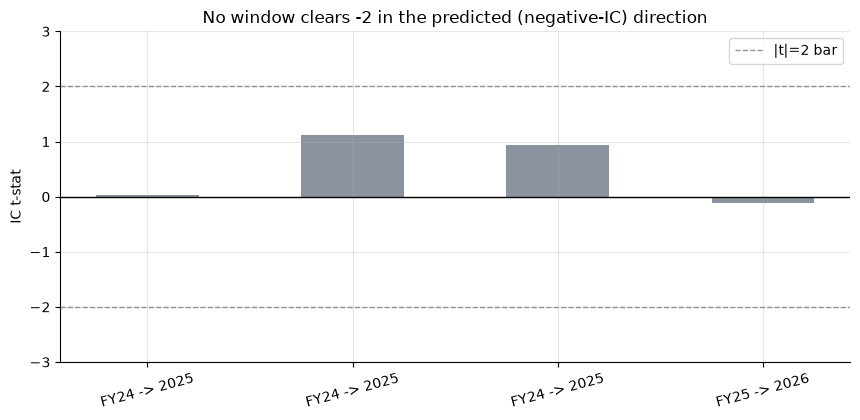

                             IC   IC_t  spread%
window                                         
FY24 -> 2025-06->2026-06  0.004  0.028  -10.167
FY24 -> 2025-06->2025-12  0.175  1.123   -2.651
FY24 -> 2025-01->2026-01  0.146  0.936  -20.446
FY25 -> 2026-02->2026-06 -0.018 -0.120   -0.151


In [4]:
wins = [('FY24 -> 2025-06->2026-06', 0.004, 0.03, -10.2), ('FY24 -> 2025-06->2025-12', 0.175, 1.12, -2.7), ('FY24 -> 2025-01->2026-01', 0.146, 0.94, -20.4), ('FY25 -> 2026-02->2026-06', -0.018, -0.12, -0.2)]
if HAVE_REAL:
    px = data.fetch_prices(fetch=False); cf = data.fetch_cashflow(fetch=False)
    spans = [('2025-06-27','2026-06-26',2024),('2025-06-27','2025-12-27',2024),
             ('2025-01-02','2026-01-02',2024),('2026-02-02','2026-06-26',2025)]
    rows = []
    for (lab,_,_,_),(sp,en,uy) in zip(wins, spans):
        pn = st.build_panel(px, cf, split_date=sp, end_date=en, upto_year=uy)
        ic = st.information_coefficient(pn); bb = st.bucket_returns(pn, 0.3)
        rows.append((lab, ic['ic'], ic['ic_t'], bb['spread']*100))
else:
    rows = wins
tab = pd.DataFrame(rows, columns=['window','IC','IC_t','spread%']).set_index('window')
fig, ax = plt.subplots(figsize=(8.7, 4.3))
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(-2, ls='--', c=GREY, lw=1, label='|t|=2 bar')
ax.axhline(0, c='k', lw=1)
ax.bar(range(len(tab)), tab['IC_t'], color=[GREEN if v<-2 else GREY for v in tab['IC_t']], width=.5)
ax.set_xticks(range(len(tab))); ax.set_xticklabels([w[:12] for w in tab.index], rotation=15)
ax.set_ylabel('IC t-stat'); ax.set_ylim(-3, 3)
ax.set_title('No window clears -2 in the predicted (negative-IC) direction'); ax.legend()
plt.tight_layout(); plt.show()
print(tab.round(3).to_string())

> 💡 In plain words: H₃ **rejected.** Every window's IC-*t* sits inside ±1.2 and the hedge spread flips between small negatives — never a *t* ≥ 2 in the predicted direction. A signal this weak and unstable is not a signal.

## 5 · The verdict

- **Signal `NONE`** — H₁ rejected (IC +0.004, *t* +0.03); H₂ rejected (spread -10.2%, *t* -0.14, wrong sign); H₃ rejected (unstable). The yfinance snapshot also caps it below REAL regardless.
- **Tradability `MIRAGE`** — survivor snapshot, binge-leg borrow; gross -10.2% → net -11.4%.
- **Capex cousin of asset growth? `BUSTED`** — vanishes like 244 and 523.

## 6 · Could you trade it? — costs and the borrow

There's no gross edge; the borrow is a footnote.

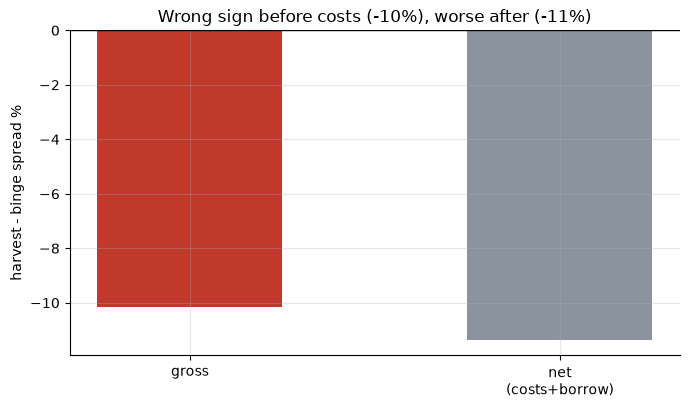

gross -10.2% -> net -11.4% (5 bps/leg + 100 bps borrow, 1y hold)


In [5]:
if HAVE_REAL:
    b = st.bucket_returns(PANEL, 0.3)
    gross = b['spread']*100
    net = st.net_spread(b, cost_bps=5.0, borrow_ann_bps=100.0, holding_years=1.0)*100
else:
    gross, net = -10.2, -11.4
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['gross','net\n(costs+borrow)'], [gross, net], color=[RED, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('harvest - binge spread %')
ax.set_title(f'Wrong sign before costs ({gross:+.0f}%), worse after ({net:+.0f}%)')
plt.tight_layout(); plt.show()
print(f'gross {gross:+.1f}% -> net {net:+.1f}% (5 bps/leg + 100 bps borrow, 1y hold)')

> 💡 In plain words: there is nothing to charge costs against — the long-harvest/short-binge book *loses* before frictions on this window. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print ~0? Plant a real capex-binge penalty (`binge_alpha < 0`) of increasing strength and watch the IC-*t* go negative — averaged over 25 seeds so no single lucky seed can fake it.

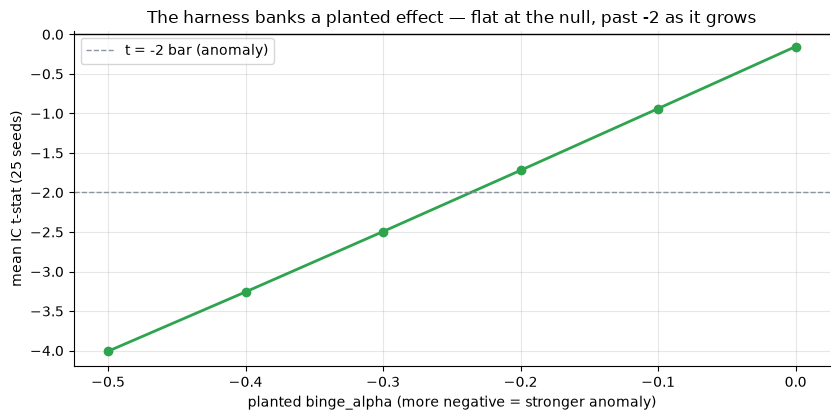

binge_alpha +0.00 -> mean IC-t -0.15
binge_alpha -0.10 -> mean IC-t -0.94
binge_alpha -0.20 -> mean IC-t -1.72
binge_alpha -0.30 -> mean IC-t -2.49
binge_alpha -0.40 -> mean IC-t -3.26
binge_alpha -0.50 -> mean IC-t -4.01


In [6]:
alphas = [0.0, -0.10, -0.20, -0.30, -0.40, -0.50]
ts = [st.synthetic_mean_ic_t(data, binge_alpha=a, n_seeds=25) for a in alphas]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(alphas, ts, 'o-', c=GREEN, lw=2)
ax.axhline(-2, ls='--', c=GREY, lw=1, label='t = -2 bar (anomaly)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted binge_alpha (more negative = stronger anomaly)')
ax.set_ylabel('mean IC t-stat (25 seeds)')
ax.set_title('The harness banks a planted effect — flat at the null, past -2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for a, t in zip(alphas, ts): print(f'binge_alpha {a:+.2f} -> mean IC-t {t:+.2f}')

The IC-*t* is ≈ 0 at the null and falls past −2 as the planted effect grows — so the engine is a faithful detector. The real-tape zero is therefore a statement about **this survivor snapshot on this window**: the capex-cycle anomaly is absent (faint wrong sign) and sign-unstable here. For the neighbours it sits between, see [244 Asset-Growth](../../244-asset-growth/) and [523 Investment-To-Assets](../../523-investment-to-assets/).